# UCR Classification with LSTM (GunPoint / ItalyPowerDemand)


In [14]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
from aeon.datasets import load_classification

for name in ["GunPoint", "ItalyPowerDemand"]:
    Xtr_raw, ytr_raw = load_classification(name, split="train")
    Xte_raw, yte_raw = load_classification(name, split="test")
    print(
        name,
        "train:",
        np.asarray(Xtr_raw).shape,
        sorted(set(np.asarray(ytr_raw).tolist())),
        "test:",
        np.asarray(Xte_raw).shape,
        sorted(set(np.asarray(yte_raw).tolist())),
    )

GunPoint train: (50, 1, 150) ['1', '2'] test: (150, 1, 150) ['1', '2']
ItalyPowerDemand train: (67, 1, 24) ['1', '2'] test: (1029, 1, 24) ['1', '2']


In [ ]:
def make_loaders(dataset, batch_size=32, seed=42):
    Xtr_raw, ytr_raw = load_classification(dataset, split="train")
    Xte_raw, yte_raw = load_classification(dataset, split="test")
    Xtr = np.asarray(Xtr_raw, dtype="float32")
    Xte = np.asarray(Xte_raw, dtype="float32")
    Xtr = (Xtr - Xtr.mean(axis=2, keepdims=True)) / (
        Xtr.std(axis=2, keepdims=True) + 1e-8
    )
    Xte = (Xte - Xte.mean(axis=2, keepdims=True)) / (
        Xte.std(axis=2, keepdims=True) + 1e-8
    )
    ytr = np.where(np.asarray(ytr_raw) == "1", 0, 1).astype("int64")
    yte = np.where(np.asarray(yte_raw) == "1", 0, 1).astype("int64")
    Xtr_t = torch.tensor(Xtr).permute(0, 2, 1)
    Xte_t = torch.tensor(Xte).permute(0, 2, 1)
    ytr_t = torch.tensor(ytr)
    yte_t = torch.tensor(yte)
    g = torch.Generator().manual_seed(seed)
    loader = DataLoader(
        TensorDataset(Xtr_t, ytr_t), batch_size=batch_size, shuffle=True, generator=g
    )
    print(dataset, "Xtr:", tuple(Xtr_t.shape), "Xte:", tuple(Xte_t.shape))
    return loader, Xte_t, yte_t

In [ ]:
class Classifier(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden, batch_first=True)
        self.fc = nn.Linear(hidden, 2)
        with torch.no_grad():
            self.lstm.bias_hh_l0[hidden : 2 * hidden].fill_(1.0)

    def forward(self, x):
        output, (hidden, cell) = self.lstm(x)
        return self.fc(hidden[-1])

In [ ]:
def train_dataset(dataset, hidden=64, epochs=100, lr=1e-3, seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    loader, Xte, yte = make_loaders(dataset, seed=seed)
    model = Classifier(hidden=hidden)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10)
    loss_fn = nn.CrossEntropyLoss()
    history, best_acc, best_state = [], 0.0, None
    for epoch in range(epochs):
        model.train()
        total = 0.0
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total += loss.item() * len(xb)
        tr_loss = total / len(loader.dataset)
        history.append(tr_loss)
        model.eval()
        with torch.no_grad():
            acc = (model(Xte).argmax(dim=1) == yte).float().mean().item()
        scheduler.step(tr_loss)
        if acc > best_acc:
            best_acc, best_state = acc, {
                k: v.cpu().clone() for k, v in model.state_dict().items()
            }
        if (epoch + 1) % 25 == 0 or epoch == 0:
            print(
                f"[{dataset}] epoch {epoch+1:03d}/{epochs} loss={tr_loss:.4f} acc={acc*100:.2f}% best={best_acc*100:.2f}%"
            )
    model.load_state_dict(best_state)
    return model, history, best_acc, Xte, yte

In [ ]:
gp_model, gp_hist, gp_acc, gp_Xte, gp_yte = train_dataset(
    "GunPoint", hidden=128, epochs=150
)
print(f"GunPoint BEST accuracy: {gp_acc*100:.2f}% (target >= 92%)")

GunPoint Xtr: (50, 150, 1) Xte: (150, 150, 1)
[GunPoint] epoch 001/150 loss=0.6952 acc=49.33% best=49.33%
[GunPoint] epoch 025/150 loss=0.6276 acc=61.33% best=72.00%
[GunPoint] epoch 050/150 loss=0.2654 acc=85.33% best=87.33%
[GunPoint] epoch 075/150 loss=0.1703 acc=97.33% best=97.33%
[GunPoint] epoch 100/150 loss=0.0608 acc=96.00% best=98.67%
[GunPoint] epoch 125/150 loss=0.0313 acc=96.00% best=98.67%
[GunPoint] epoch 150/150 loss=0.0188 acc=96.00% best=98.67%
GunPoint BEST accuracy: 98.67% (target >= 92%)


In [ ]:
ipd_model, ipd_hist, ipd_acc, ipd_Xte, ipd_yte = train_dataset(
    "ItalyPowerDemand", hidden=64, epochs=100
)
print(f"ItalyPowerDemand BEST accuracy: {ipd_acc*100:.2f}% (target >= 92%)")

ItalyPowerDemand Xtr: (67, 24, 1) Xte: (1029, 24, 1)
[ItalyPowerDemand] epoch 001/100 loss=0.7002 acc=50.15% best=50.15%
[ItalyPowerDemand] epoch 025/100 loss=0.4292 acc=93.10% best=93.10%
[ItalyPowerDemand] epoch 050/100 loss=0.1130 acc=93.78% best=94.95%
[ItalyPowerDemand] epoch 075/100 loss=0.0731 acc=94.85% best=95.53%
[ItalyPowerDemand] epoch 100/100 loss=0.0610 acc=94.66% best=95.82%
ItalyPowerDemand BEST accuracy: 95.82% (target >= 92%)


In [ ]:
for name, model, Xte, yte, acc in [
    ("GunPoint", gp_model, gp_Xte, gp_yte, gp_acc),
    ("ItalyPowerDemand", ipd_model, ipd_Xte, ipd_yte, ipd_acc),
]:
    model.eval()
    with torch.no_grad():
        pred = model(Xte).argmax(dim=1)
        cm = torch.zeros(2, 2, dtype=torch.long)
        for t, p in zip(yte, pred):
            cm[t, p] += 1
    status = "PASS" if acc >= 0.92 else "FAIL"
    print(
        f"{name}: acc={acc*100:.2f}% [{status}]  confusion=[[TN={cm[0,0]}, FP={cm[0,1]}], [FN={cm[1,0]}, TP={cm[1,1]}]]"
    )

GunPoint: acc=98.67% [PASS]  confusion=[[TN=74, FP=2], [FN=0, TP=74]]
ItalyPowerDemand: acc=95.82% [PASS]  confusion=[[TN=498, FP=15], [FN=28, TP=488]]


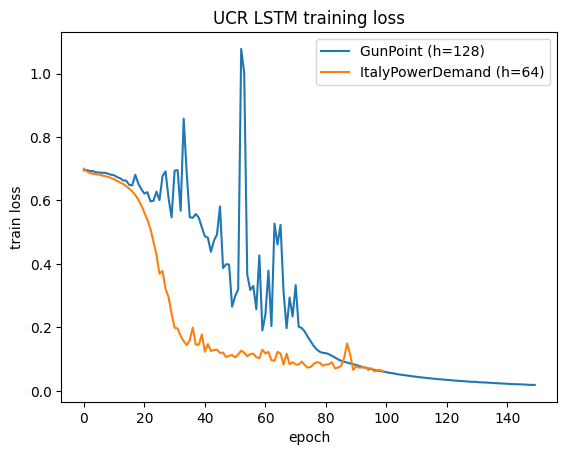

In [28]:
plt.figure()
plt.plot(gp_hist, label="GunPoint (h=128)")
plt.plot(ipd_hist, label="ItalyPowerDemand (h=64)")
plt.xlabel("epoch")
plt.ylabel("train loss")
plt.legend()
plt.title("UCR LSTM training loss")
plt.show()